In [1]:
# Import the libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Read the European data and convert the time to Central European time, the time of the market
prices = pd.read_csv("../data/europe_prices.csv", index_col="time_utc")
production = pd.read_csv("../data/europe_production.csv", index_col="time_utc")
prices.index = pd.to_datetime(prices.index, utc=True).tz_convert("Europe/Brussels")
production.index = pd.to_datetime(production.index, utc=True).tz_convert("Europe/Brussels")
prices.index.name = "time"
production.index.name = "time"

In [2]:
# Readable names for the bidding zones
names = {"PT": "Portugal", "ES": "Spain", "FR": "France", "BE": "Belgium", "NL": "Netherlands",
         "DE_LU": "Germany", "AT": "Austria", "CH": "Switzerland", "IT_NORD": "Italy (North)",
         "PL": "Poland", "CZ": "Czechia", "SK": "Slovakia", "HU": "Hungary", "SI": "Slovenia",
         "HR": "Croatia", "RO": "Romania", "BG": "Bulgaria", "GR": "Greece", "DK_1": "Denmark (West)",
         "SE_3": "Sweden (South)", "NO_1": "Norway (Oslo)", "FI": "Finland", "EE": "Estonia",
         "LV": "Latvia", "LT": "Lithuania", "IE_SEM": "Ireland"}

# Horizontal bar chart sorted from lowest to highest, with Portugal in red
def ranking_chart(values, title, xlabel, file):
    values = values.dropna().sort_values().rename(index=names)
    colors = ["tab:red" if zone == "Portugal" else "tab:gray" for zone in values.index]
    plt.figure(figsize=(8, 7))
    plt.barh(values.index, values, color=colors)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.tight_layout()
    plt.savefig("../figures/" + file, dpi=150)
    plt.show()

In [3]:
# Save the prices in the SQLite database, one row per hour and zone
prices_long = prices.reset_index().melt(id_vars="time", var_name="zone", value_name="price").dropna()
prices_long["time"] = prices_long["time"].astype(str)
con = sqlite3.connect("../data/electricity.db")
prices_long.to_sql("europe_prices", con, if_exists="replace", index=False)
print(len(prices_long), "rows")

1770291 rows


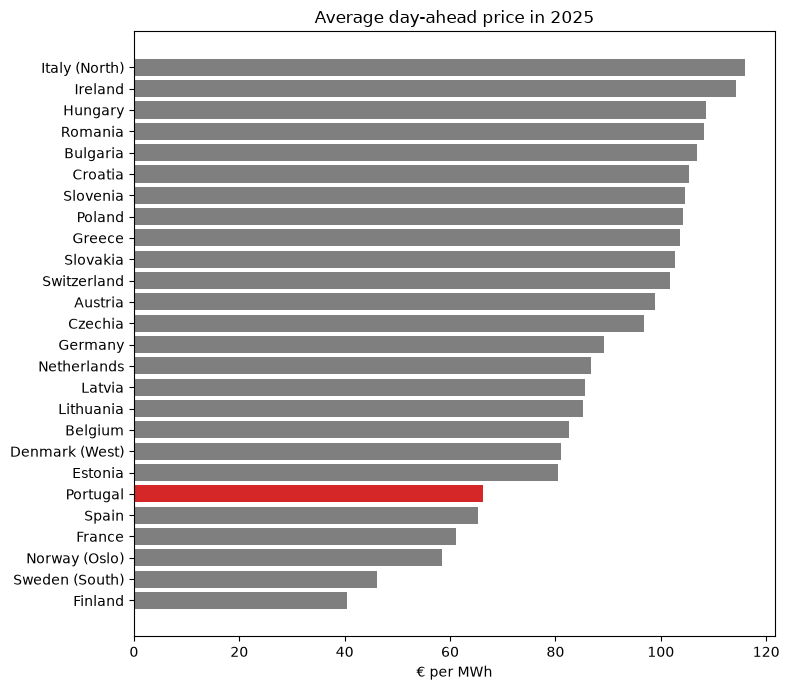

In [11]:
# 1. Average price in 2025 in each zone
query = """
SELECT zone, ROUND(AVG(price), 1) AS average_price
FROM europe_prices
WHERE substr(time, 1, 4) = '2025'
GROUP BY zone
ORDER BY average_price DESC
"""
ranking = pd.read_sql(query, con).set_index("zone")
ranking_chart(ranking["average_price"], "Average day-ahead price in 2025", "€ per MWh", "europe_price_ranking.png")